In [15]:
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import os

# ==========================================
# 1. EXTRACCIÓN Y DIAGNÓSTICO DE DATOS
# ==========================================
print("\n" + "="*50)
print(" EXTRACCIÓN Y MUESTRA DE DATOS")
print("="*50)

url_repositorio = "https://ti.arc.nasa.gov/m/project/prognostic-repository/CMAPSSData.zip"
archivo_zip = "CMAPSSData.zip"
directorio_extraccion = "./datos_motor"

if not os.path.exists(directorio_extraccion):
    os.makedirs(directorio_extraccion)
    print("⏳ Descargando dataset de la NASA...")
    req = urllib.request.Request(url_repositorio, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(archivo_zip, 'wb') as out_file:
        out_file.write(response.read())
    with zipfile.ZipFile(archivo_zip, 'r') as zip_ref:
        zip_ref.extractall(directorio_extraccion)
    os.remove(archivo_zip)

# Nombres de columnas (El dataset original no tiene encabezados)
column_names = ['unit_number', 'time_in_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
column_names.extend(sensor_names)

ruta_train = os.path.join(directorio_extraccion, 'train_FD001.txt')
df_train = pd.read_csv(ruta_train, sep=r'\s+', header=None, names=column_names)

print(f"Datos cargados exitosamente: {df_train.shape[0]} filas y {df_train.shape[1]} columnas.")

# --- NUEVO CÓDIGO: GENERACIÓN DE AYUDA VISUAL (FRACCIÓN DE DATOS) ---
print("\n Muestra de los primeros 5 registros del Motor #1")
# Seleccionamos algunas columnas clave para que la tabla se vea bien en la terminal
columnas_visuales = ['unit_number', 'time_in_cycles', 'op_setting_1', 'sensor_2', 'sensor_3', 'sensor_4']
cuadro_datos = df_train[columnas_visuales].head()

# Imprimimos la tabla formateada sin el índice para mayor limpieza
print("-" * 75)
print(cuadro_datos.to_string(index=False))
print("-" * 75)



 EXTRACCIÓN Y MUESTRA DE DATOS
Datos cargados exitosamente: 20631 filas y 26 columnas.

 Muestra de los primeros 5 registros del Motor #1
---------------------------------------------------------------------------
 unit_number  time_in_cycles  op_setting_1  sensor_2  sensor_3  sensor_4
           1               1       -0.0007    641.82   1589.70   1400.60
           1               2        0.0019    642.15   1591.82   1403.14
           1               3       -0.0043    642.35   1587.99   1404.20
           1               4        0.0007    642.35   1582.79   1401.87
           1               5       -0.0019    642.37   1582.85   1406.22
---------------------------------------------------------------------------


In [16]:
# ==========================================
# 2. CÁLCULO DEL RUL Y LIMPIEZA DE DATOS
# ==========================================
print("\n" + "="*50)
print("CÁLCULO DE RUL Y LIMPIEZA")
print("="*50)

# 1. Calculamos el ciclo máximo (momento de falla) para cada motor
max_cycles = df_train.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycles']

# 2. Cruzamos la información y restamos para obtener el RUL exacto
df_train = df_train.merge(max_cycles, on='unit_number', how='left')
df_train['RUL'] = df_train['max_cycles'] - df_train['time_in_cycles']
df_train.drop('max_cycles', axis=1, inplace=True)

# 3. Limpieza: Sensores con varianza cero en FD001 (ruido que no aporta al desgaste)
sensores_basura = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
df_train.drop(columns=sensores_basura, inplace=True)

print("Transformación completada: RUL calculado (Nueva variable objetivo) y sensores limpios.")

# --- GENERACIÓN DE AYUDA VISUAL (EVOLUCIÓN DEL RUL) ---
print("\n Evolución de la degradación en el Motor #1 (Contraste Inicio vs Fin)")

# Seleccionamos columnas clave para mostrar cómo cambian los sensores y el RUL
columnas_visuales_rul = ['unit_number', 'time_in_cycles', 'sensor_2', 'sensor_11', 'RUL']

# Extraemos los primeros 3 ciclos (Motor sano) y los últimos 3 ciclos (Motor a punto de fallar)
motor_1 = df_train[df_train['unit_number'] == 1]
cuadro_rul = pd.concat([motor_1.head(3), motor_1.tail(3)])[columnas_visuales_rul]

print("-" * 65)
print(cuadro_rul.to_string(index=False))
print("-" * 65)



CÁLCULO DE RUL Y LIMPIEZA
Transformación completada: RUL calculado (Nueva variable objetivo) y sensores limpios.

 Evolución de la degradación en el Motor #1 (Contraste Inicio vs Fin)
-----------------------------------------------------------------
 unit_number  time_in_cycles  sensor_2  sensor_11  RUL
           1               1    641.82      47.47  191
           1               2    642.15      47.49  190
           1               3    642.35      47.27  189
           1             190    643.64      48.33    2
           1             191    643.34      48.15    1
           1             192    643.54      48.25    0
-----------------------------------------------------------------


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

# 3. ENTRENAMIENTO DEL GEMELO DIGITAL (MODELO)

print("\n" + "="*50)
print("ENTRENAMIENTO Y MÉTRICAS DE ERROR")
print("="*50)

# 1. Definimos qué va a leer el modelo (features) y qué debe adivinar (objetivo)
features = [c for c in df_train.columns if 'sensor' in c or 'op_setting' in c]
X = df_train[features]
y = df_train['RUL']

# 2. Separamos los datos: 80% para entrenar, 20% para ponerlo a prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Normalizamos (Escalamos) los datos para que el modelo no se confunda con las diferentes unidades
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entrenamos el "cerebro" del Gemelo Digital
print("Entrenando el modelo RandomForestRegressor (Puede tomar unos segundos)...")
# Usamos n_jobs=-1 para que tu computadora use todos sus núcleos y termine más rápido
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# 5. Ponemos a prueba el modelo con el 20% de datos que no conoce
y_pred = rf_model.predict(X_test_scaled)

# 6. Calculamos sus calificaciones (Métricas matemáticas)
mae = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Entrenamiento completado exitosamente.")

# --- GENERACIÓN DE AYUDA VISUAL (MÉTRICAS DE RENDIMIENTO) ---
print("\n Rendimiento del Gemelo Digital (Métricas de Evaluación)")
print("-" * 65)
print(f"* Error Absoluto Medio (MAE):         {mae:.2f} ciclos")
print(f"* Raíz del Error Cuadrático (RMSE):   {rmse:.2f} ciclos")
print(f"* Coeficiente de Determinación (R²):  {r2:.4f}")
print("-" * 65)




ENTRENAMIENTO Y MÉTRICAS DE ERROR
Entrenando el modelo RandomForestRegressor (Puede tomar unos segundos)...
Entrenamiento completado exitosamente.

 Rendimiento del Gemelo Digital (Métricas de Evaluación)
-----------------------------------------------------------------
* Error Absoluto Medio (MAE):         29.45 ciclos
* Raíz del Error Cuadrático (RMSE):   41.23 ciclos
* Coeficiente de Determinación (R²):  0.6279
-----------------------------------------------------------------



SIMULACIÓN DEL GEMELO DIGITAL (MOTOR #1)

 AYUDA VISUAL: Comparativa Real vs Predicho (Últimos 5 ciclos)
-------------------------------------------------------
 time_in_cycles  RUL  RUL_Predicho
            188    4           5.9
            189    3           3.7
            190    2           3.0
            191    1           2.8
            192    0           2.7
-------------------------------------------------------
Gráfica generada y guardada como '01_gemelo_digital_motor1.png'.


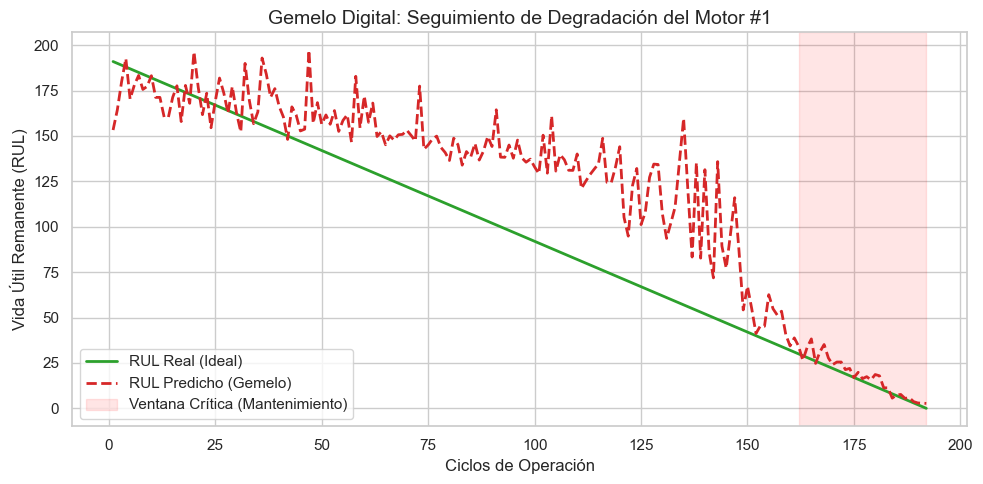

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns


# 4. VISUALIZACIÓN DEL GEMELO DIGITAL (SERIE TEMPORAL)

print("\n" + "="*50)
print("SIMULACIÓN DEL GEMELO DIGITAL (MOTOR #1)")
print("="*50)

sns.set_theme(style="whitegrid")

# 1. Extraemos toda la historia del Motor 1
unidad = 1
datos_unidad = df_train[df_train['unit_number'] == unidad].copy()

# 2. El modelo predice el RUL paso a paso
X_unidad = scaler.transform(datos_unidad[features])
datos_unidad['RUL_Predicho'] = rf_model.predict(X_unidad)

# --- GENERACIÓN DE AYUDA VISUAL EN TERMINAL ---
print("\n AYUDA VISUAL: Comparativa Real vs Predicho (Últimos 5 ciclos)")
columnas_comparativa = ['time_in_cycles', 'RUL', 'RUL_Predicho']
cuadro_comparativo = datos_unidad.tail(5)[columnas_comparativa].copy()
cuadro_comparativo['RUL_Predicho'] = cuadro_comparativo['RUL_Predicho'].round(1)

print("-" * 55)
print(cuadro_comparativo.to_string(index=False))
print("-" * 55)


# 3. Generación de la Gráfica
plt.figure(figsize=(10, 5))
plt.plot(datos_unidad['time_in_cycles'], datos_unidad['RUL'], label='RUL Real (Ideal)', color='#2ca02c', linewidth=2)
plt.plot(datos_unidad['time_in_cycles'], datos_unidad['RUL_Predicho'], label='RUL Predicho (Gemelo)', color='#d62728', linestyle='--', linewidth=2)

plt.axvspan(datos_unidad['time_in_cycles'].max() - 30, datos_unidad['time_in_cycles'].max(), color='red', alpha=0.1, label='Ventana Crítica (Mantenimiento)')
plt.title(f'Gemelo Digital: Seguimiento de Degradación del Motor #{unidad}', fontsize=14)
plt.xlabel('Ciclos de Operación', fontsize=12)
plt.ylabel('Vida Útil Remanente (RUL)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('01_gemelo_digital_motor1.png')
print("Gráfica generada y guardada como '01_gemelo_digital_motor1.png'.")
plt.show() # Cierra la ventana de la gráfica para continuar


EXPLICABILIDAD DE RESULTADOS

 AYUDA VISUAL: Top 3 variables que indican degradación
---------------------------------------------
   Sensor Importancia
sensor_11     44.13 %
 sensor_9     12.82 %
 sensor_4     12.59 %
---------------------------------------------
En el dataset CMAPSS, el sensor_11 
(Temperatura de turbina) suele ser el indicador más fuerte de fallo.
Gráfica generada y guardada como '02_explicabilidad_sensores.png'.


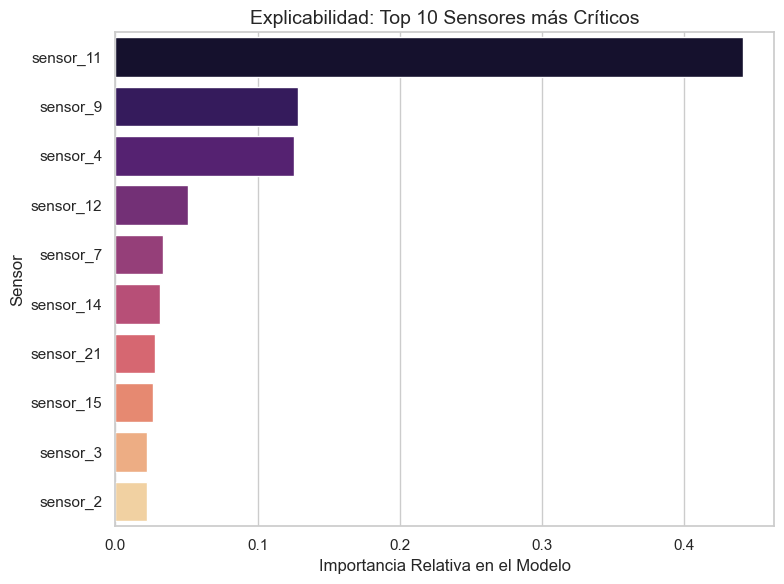

In [19]:

# 5. EXPLICABILIDAD: IMPORTANCIA DE VARIABLES

print("\n" + "="*50)
print("EXPLICABILIDAD DE RESULTADOS")
print("="*50)

# 1. Extraemos el peso que el Random Forest le dio a cada sensor
importancias = rf_model.feature_importances_
df_importancia = pd.DataFrame({'Sensor': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# --- GENERACIÓN DE AYUDA VISUAL EN TERMINAL ---
print("\n AYUDA VISUAL: Top 3 variables que indican degradación")
top_3 = df_importancia.head(3).copy()
top_3['Importancia'] = (top_3['Importancia'] * 100).round(2).astype(str) + ' %'
print("-" * 45)
print(top_3.to_string(index=False))
print("-" * 45)
print("En el dataset CMAPSS, el sensor_11 ")
print("(Temperatura de turbina) suele ser el indicador más fuerte de fallo.")

# 2. Generación de la Gráfica de Explicabilidad
plt.figure(figsize=(8, 6))
sns.barplot(x='Importancia', y='Sensor', data=df_importancia.head(10), hue='Sensor', palette='magma', legend=False)
plt.title('Explicabilidad: Top 10 Sensores más Críticos', fontsize=14)
plt.xlabel('Importancia Relativa en el Modelo', fontsize=12)
plt.ylabel('Sensor', fontsize=12)
plt.tight_layout()
plt.savefig('02_explicabilidad_sensores.png')
print("Gráfica generada y guardada como '02_explicabilidad_sensores.png'.")
plt.show()


SIMULACIÓN DE MEJORA Y MÉTRICAS DE NEGOCIO

 Impacto de la Propuesta de Optimización
---------------------------------------------------------------------------
🔸 Acción Propuesta:   Mejora de refrigeración (-1.5% en lectura de sensor_11)
🔸 Ciclos Ganados:     +35.07 ciclos de vida útil promedio.
🔸 Ahorro Estimado:    $35,000 USD por motor al evitar falla catastrófica.
---------------------------------------------------------------------------
 Gráfica generada y guardada como '03_optimizacion_simulada.png'.


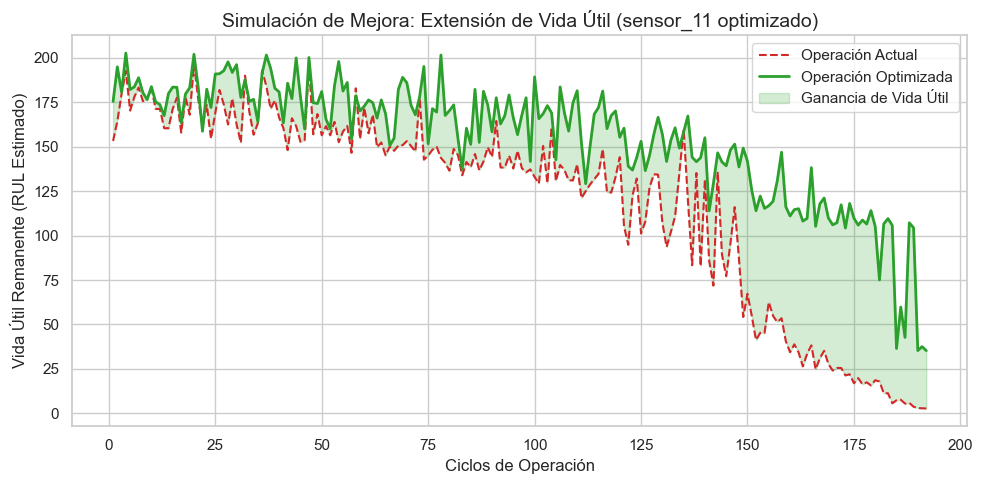

In [20]:

# 6. OPTIMIZACIÓN Y CÁLCULO DE IMPACTO (EXCELENCIA)

print("\n" + "="*50)
print("SIMULACIÓN DE MEJORA Y MÉTRICAS DE NEGOCIO")
print("="*50)

sensor_top = df_importancia.iloc[0]['Sensor']
datos_simulacion = df_train[df_train['unit_number'] == 1].copy()

# 1. ESCENARIO DE OPTIMIZACIÓN: Reducimos el estrés del sensor principal en 1.5%
datos_simulacion[sensor_top] = datos_simulacion[sensor_top] * 0.985

# 2. El Gemelo Digital predice la nueva vida útil con esta mejora
X_simulacion = scaler.transform(datos_simulacion[features])
datos_simulacion['RUL_Optimizado'] = rf_model.predict(X_simulacion)

# 3. CÁLCULOS PARA LA EXCELENCIA (MÉTRICAS DE NEGOCIO)
ganancia_ciclos_promedio = (datos_simulacion['RUL_Optimizado'] - datos_unidad['RUL_Predicho']).mean()
# Supuestos de negocio para el informe:
costo_falla_imprevista = 50000 # Dólares
costo_mantenimiento_preventivo = 15000 # Dólares
ahorro_por_motor = costo_falla_imprevista - costo_mantenimiento_preventivo

# --- GENERACIÓN DE AYUDA VISUAL EN TERMINAL ---
print("\n Impacto de la Propuesta de Optimización")
print("-" * 75)
print(f"🔸 Acción Propuesta:   Mejora de refrigeración (-1.5% en lectura de {sensor_top})")
print(f"🔸 Ciclos Ganados:     +{ganancia_ciclos_promedio:.2f} ciclos de vida útil promedio.")
print(f"🔸 Ahorro Estimado:    ${ahorro_por_motor:,} USD por motor al evitar falla catastrófica.")
print("-" * 75)


# 4. Generación de la Gráfica de Optimización
plt.figure(figsize=(10, 5))
plt.plot(datos_unidad['time_in_cycles'], datos_unidad['RUL_Predicho'], label='Operación Actual', color='#d62728', linestyle='--')
plt.plot(datos_simulacion['time_in_cycles'], datos_simulacion['RUL_Optimizado'], label='Operación Optimizada', color='#2ca02c', linewidth=2)

plt.fill_between(datos_simulacion['time_in_cycles'], datos_unidad['RUL_Predicho'], datos_simulacion['RUL_Optimizado'], color='#2ca02c', alpha=0.2, label='Ganancia de Vida Útil')
plt.title(f'Simulación de Mejora: Extensión de Vida Útil ({sensor_top} optimizado)', fontsize=14)
plt.xlabel('Ciclos de Operación', fontsize=12)
plt.ylabel('Vida Útil Remanente (RUL Estimado)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('03_optimizacion_simulada.png')
print(" Gráfica generada y guardada como '03_optimizacion_simulada.png'.")
plt.show()